In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split,GridSearchCV

In [2]:
# Reading the dataset
df=pd.read_excel("glass.xlsx",sheet_name="glass")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [6]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [7]:
# Check missing values
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [8]:
# Checking for duplicates
df.duplicated().sum()

np.int64(1)

In [3]:
# droping the duplicates
df.drop_duplicates(inplace=True,ignore_index=True)
df.duplicated().sum() # shows duplicated values are removed

np.int64(0)

<Axes: >

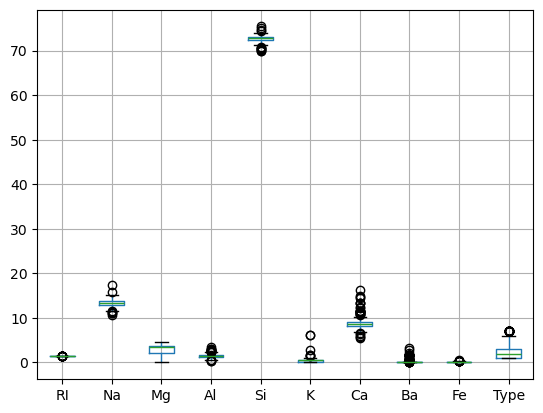

In [10]:
# checking for outliers
df.boxplot()

In [4]:
# Outlier treatment using IQR capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25) # calculating Q1
    Q3= df[columns].quantile(0.75) # calculating Q3
    IQR= Q3-Q1 # calculating IQR
    lower_extreme= Q1-1.5*IQR # calculating Lower_extreme
    upper_extreme= Q3+1.5*IQR # calculating upper extreme
    df[columns]=df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
# replacing values less than lower_extreme with lower_extreme and values greater than upper_extreme with upper_extreme
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

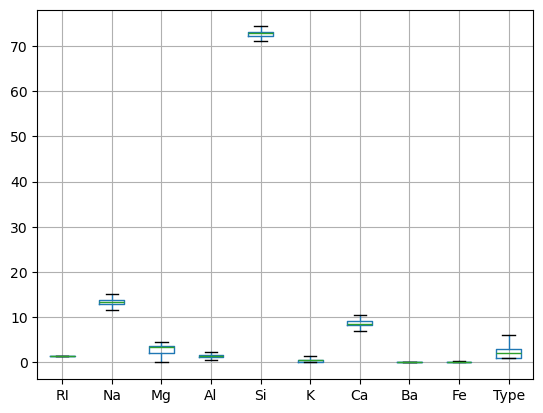

In [14]:
df.boxplot()
plt.show()# shows outliers are treated

In [13]:
df.describe() # statistical summary

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.0,213.000000,213.000000
mean,1.518145,13.401244,2.679202,1.424977,72.673146,0.441972,8.788146,0.0,0.053099,2.652582
std,0.002361,0.741659,1.443691,0.420895,0.657750,0.305433,0.860782,0.0,0.085692,1.843258
min,1.512575,11.535000,0.000000,0.530000,71.065000,0.000000,6.875000,0.0,0.000000,1.000000
25%,1.516520,12.900000,2.090000,1.190000,72.280000,0.130000,8.240000,0.0,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.560000,8.600000,0.0,0.000000,2.000000
75%,1.519150,13.810000,3.600000,1.630000,73.090000,0.610000,9.150000,0.0,0.100000,3.000000
max,1.523095,15.175000,4.490000,2.290000,74.305000,1.330000,10.515000,0.0,0.250000,6.000000


array([[<Axes: title={'center': 'RI'}>, <Axes: title={'center': 'Na'}>,
        <Axes: title={'center': 'Mg'}>],
       [<Axes: title={'center': 'Al'}>, <Axes: title={'center': 'Si'}>,
        <Axes: title={'center': 'K'}>],
       [<Axes: title={'center': 'Ca'}>, <Axes: title={'center': 'Ba'}>,
        <Axes: title={'center': 'Fe'}>],
       [<Axes: title={'center': 'Type'}>, <Axes: >, <Axes: >]],
      dtype=object)

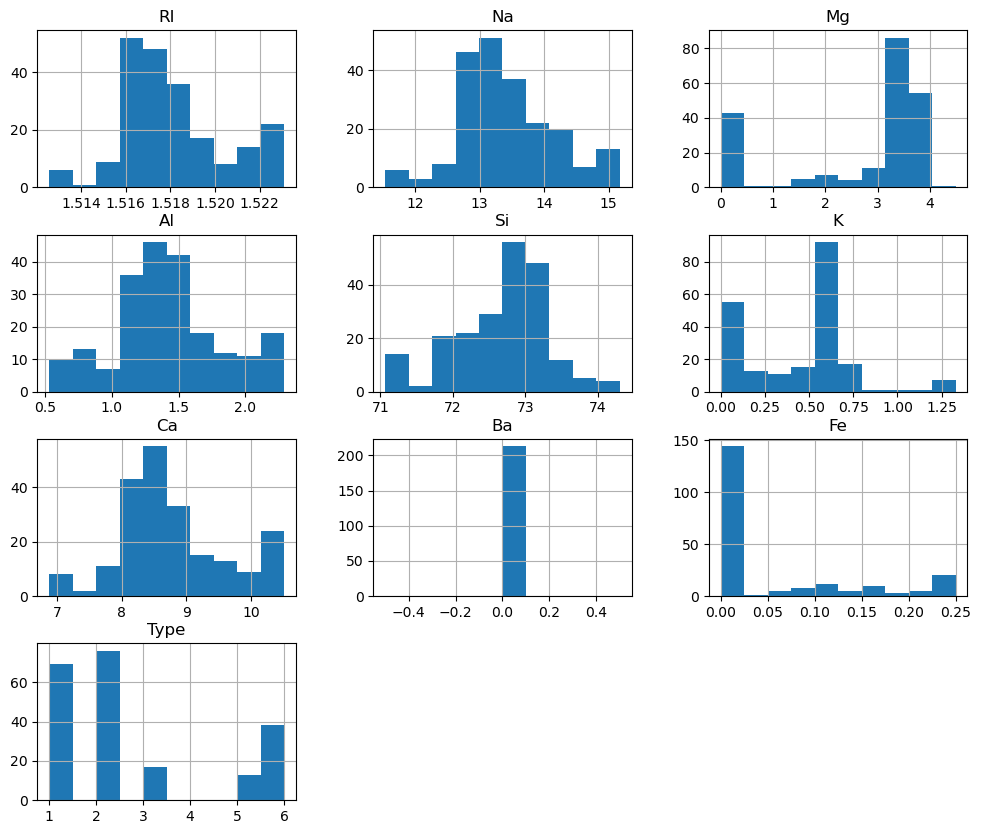

In [5]:
# Histogram
df.hist(figsize=(12,10))



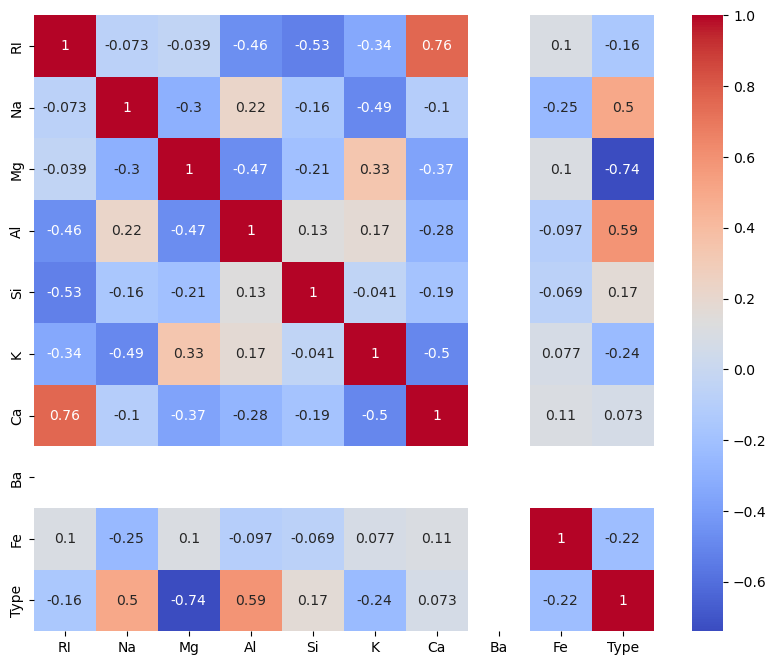

In [19]:
#Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [6]:
#Feature & Target Separation
features= df.drop(columns=['Type'])
target= df[['Type']]

In [7]:
# Splitting the dataset into train and test
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=150,stratify=target)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(170, 9)
(43, 9)
(170, 1)
(43, 1)


In [8]:
# Feature Scaling
std_sca=StandardScaler()

In [23]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1.0


In [9]:
# Scaling  features
x_train[['RI','Na','Mg','Al','Si','K','Ca']]= std_sca.fit_transform(x_train[['RI','Na','Mg','Al','Si','K','Ca']]) # for training use fit_transform
# Scaling x test features
x_test[['RI','Na','Mg','Al','Si','K','Ca']]= std_sca.transform(x_test[['RI','Na','Mg','Al','Si','K','Ca']])# for testing use tranform


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(x_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [27]:
x_train.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
160,0.509306,0.315823,0.549017,-1.600156,0.000274,-0.943047,0.204218,0.0,0.24
66,1.409718,-0.471087,0.627864,-1.315981,-0.512516,-0.842618,1.354065,0.0,0.17
147,-0.581101,-0.217675,0.570521,-0.108237,0.077970,0.396005,-0.334773,0.0,0.10
207,-0.705011,1.289458,-1.988411,2.046756,0.311056,-1.478667,0.874962,0.0,0.00
74,-0.911528,-0.511099,0.577689,0.199619,0.730611,0.831197,-0.909697,0.0,0.00


In [11]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7441860465116279
              precision    recall  f1-score   support

         1.0       0.76      0.93      0.84        14
         2.0       0.90      0.60      0.72        15
         3.0       0.33      0.33      0.33         3
         5.0       0.40      0.67      0.50         3
         6.0       0.88      0.88      0.88         8

    accuracy                           0.74        43
   macro avg       0.65      0.68      0.65        43
weighted avg       0.78      0.74      0.75        43



In [13]:
# Bagging with Logistic regression modelm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
bag_clas= BaggingClassifier(estimator=LogisticRegression(), n_estimators=50, max_samples=0.9, 
                            max_features=1, bootstrap=True, bootstrap_features=True,random_state=50,oob_score=True)
bag_clas.fit(x_train,y_train)
y_pred= bag_clas.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.4418604651162791
              precision    recall  f1-score   support

         1.0       0.30      0.21      0.25        14
         2.0       0.39      0.73      0.51        15
         3.0       0.00      0.00      0.00         3
         5.0       0.00      0.00      0.00         3
         6.0       1.00      0.62      0.77         8

    accuracy                           0.44        43
   macro avg       0.34      0.31      0.31        43
weighted avg       0.42      0.44      0.40        43



In [14]:
# Bagging with Decision tree model
from sklearn.ensemble import BaggingClassifier
bag_clas= BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, max_samples=0.9, 
                            max_features=1, bootstrap=True, bootstrap_features=True,random_state=50,oob_score=True)
bag_clas.fit(x_train,y_train)
y_pred= bag_clas.predict(x_test)
accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6511627906976745
              precision    recall  f1-score   support

         1.0       0.75      0.86      0.80        14
         2.0       0.59      0.67      0.62        15
         3.0       0.00      0.00      0.00         3
         5.0       0.00      0.00      0.00         3
         6.0       0.60      0.75      0.67         8

    accuracy                           0.65        43
   macro avg       0.39      0.45      0.42        43
weighted avg       0.56      0.65      0.60        43



In [15]:
# Adaboost with logistic regression model
from sklearn.ensemble import AdaBoostClassifier
ada_boost= AdaBoostClassifier(estimator=LogisticRegression(),n_estimators=100,random_state=50)
ada_boost.fit(x_train,y_train)
y_pred= ada_boost.predict(x_test)
accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5813953488372093
              precision    recall  f1-score   support

         1.0       0.67      0.29      0.40        14
         2.0       0.48      0.80      0.60        15
         3.0       1.00      0.33      0.50         3
         5.0       0.67      0.67      0.67         3
         6.0       0.75      0.75      0.75         8

    accuracy                           0.58        43
   macro avg       0.71      0.57      0.58        43
weighted avg       0.64      0.58      0.56        43



In [16]:
#Adaboost with decision tree model
ada_boost= AdaBoostClassifier(estimator=DecisionTreeClassifier(),n_estimators=100,random_state=50)
ada_boost.fit(x_train,y_train)
y_pred= ada_boost.predict(x_test)
accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.627906976744186
              precision    recall  f1-score   support

         1.0       0.80      0.86      0.83        14
         2.0       0.86      0.40      0.55        15
         3.0       0.25      0.33      0.29         3
         5.0       0.29      0.67      0.40         3
         6.0       0.60      0.75      0.67         8

    accuracy                           0.63        43
   macro avg       0.56      0.60      0.55        43
weighted avg       0.71      0.63      0.63        43



In [17]:
#GRadientboost classifier
from sklearn.ensemble import GradientBoostingClassifier
grad_boost= GradientBoostingClassifier(n_estimators=100,learning_rate=0.5, subsample=0.9,max_features=1)
grad_boost.fit(x_train,y_train)
y_pred= grad_boost.predict(x_test)
accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7209302325581395
              precision    recall  f1-score   support

         1.0       0.68      0.93      0.79        14
         2.0       0.82      0.60      0.69        15
         3.0       0.33      0.33      0.33         3
         5.0       0.50      0.33      0.40         3
         6.0       0.88      0.88      0.88         8

    accuracy                           0.72        43
   macro avg       0.64      0.61      0.62        43
weighted avg       0.73      0.72      0.71        43



In [ ]:
1. Bagging with Logistic Regression – Worst Performance (44.2%)
2. Bagging with Decision Tree – Moderate Performance (65.1%)
3. AdaBoost with Logistic Regression – Improved but Limited (58.1%)
4.Gradient Boosting Classifier – Strong Performance (72.1%)
5. Random Forest – Best Performance (74.4%)
Random Forest is the most stable and accurate model for the Glass dataset.

In [ ]:
1. Bagging (Bootstrap Aggregating)
Definition:
Bagging is an ensemble learning technique that improves model performance by reducing variance. It trains multiple models independently on different random samples of the training data and combines their predictions.

How Bagging Works:

Multiple datasets are created using bootstrap sampling (sampling with replacement).

A base learner (usually a decision tree) is trained on each dataset.

Predictions from all models are combined using:

Majority voting (classification)

Averaging (regression)

Key Characteristics:

Models are trained in parallel

Each model has equal importance

Works best with high-variance models

Example:

Random Forest is a classic example of Bagging.

2. Boosting
Definition:

Boosting is an ensemble learning technique that improves model performance by reducing bias and variance. It trains models sequentially, where each new model focuses on correcting the mistakes made by the previous ones.

How Boosting Works:

Initially, all training samples have equal weight.

After each model is trained, misclassified samples receive higher weights.

New models focus more on hard-to-classify instances.

Final prediction is a weighted combination of all models.

Key Characteristics:

Models are trained sequentially

More importance is given to misclassified samples

Works well with weak learners

Examples:

AdaBoost

Gradient Boosting

XGBoost

In [ ]:
Explain how to handle imbalance in the data.

A dataset is said to be imbalanced when one or more classes have significantly fewer samples than others.
Example: 90% Class A and 10% Class B.

This causes models to become biased toward the majority class, giving misleadingly high accuracy.

Techniques to Handle Imbalanced Data:

1.Class Weight Adjustment

Method:

Assign higher penalty to misclassification of minority class

2.Ensemble Methods

Multiple models reduce bias

Focus on difficult samples

Examples:

Random Forest

AdaBoost

Gradient Boosting

XGBoost